# 1. Data Acquisition

In [37]:
!pip install datasets opencv-python pillow matplotlib numpy

In [38]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset

# Centralized Parameters Configuration
TARGET_HEIGHT = 64
MAX_WIDTH = 1024
BATCH_SIZE = 32

# Index 0 is strictly reserved for the CTC blank token '-'
CHAR_LIST = "- abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.,:;?!'\"-()"
CHAR_TO_NUM = {char: idx for idx, char in enumerate(CHAR_LIST)}
NUM_TO_CHAR = {idx: char for idx, char in enumerate(CHAR_LIST)}
NUM_CLASSES = len(CHAR_LIST)

In [39]:
def load_handwriting_data():
    raw_dataset = load_dataset("Teklia/IAM-line")
    train_samples = []
    val_samples = []
    
    # Process the Training Split
    print("Processing training partitions...")
    for item in raw_dataset['train']:
        # Hugging Face returns a PIL Image object; convert it to a grayscale NumPy array for OpenCV
        gray_img = np.array(item['image'].convert('L'))
        text_label = item['text']
        
        # Skip empty labels or corrupted images if any exist
        if text_label.strip():
            train_samples.append({
                'image': gray_img,
                'text': text_label
            })
            
    # Process the Validation Split
    print("Processing validation partitions...")
    for item in raw_dataset['validation']:
        gray_img = np.array(item['image'].convert('L'))
        text_label = item['text']
        
        if text_label.strip():
            val_samples.append({
                'image': gray_img,
                'text': text_label
            })
            
    print(f"Success! Loaded {len(train_samples)} training lines and {len(val_samples)} validation lines.")
    return train_samples, val_samples

In [40]:
train_set, val_set = load_handwriting_data()
    
# Quick structural check of the first sample item
print("\n Sample Data Structural Inspection:")
print(f"Image Matrix Type: {type(train_set[0]['image'])}")
print(f"Image Pixel Dimensions: {train_set[0]['image'].shape}")
print(f"Corresponding Text Label: {train_set[0]['text']}")

Processing training partitions...
Processing validation partitions...
Success! Loaded 6482 training lines and 976 validation lines.

 Sample Data Structural Inspection:
Image Matrix Type: <class 'numpy.ndarray'>
Image Pixel Dimensions: (128, 2467)
Corresponding Text Label: put down a resolution on the subject


# 2. Data preprocessing (Image binarization and Fixed Height Padding) and Tokenization

In [41]:
class HandwritingPreprocessor:
    def __init__(self):
        self.max_width = MAX_WIDTH
        self.target_height = TARGET_HEIGHT
        self.char_to_num = CHAR_TO_NUM
        self.num_to_char = NUM_TO_CHAR

    def preprocess_image(self, img_array):
        """ Binarizes, resizes, and pads a grayscale numpy image array """
        # 1. Clean up shadows using Otsu's thresholding (Inverting so text is white, bg is black)
        _, thresh = cv2.threshold(img_array, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        
        # 2. Calculate aspect-ratio safe scaling width
        h, w = thresh.shape
        scale_factor = self.target_height / h
        new_width = int(w * scale_factor)
        
        # Limit width if it naturally exceeds our max boundary
        if new_width > self.max_width:
            new_width = self.max_width
            
        # Resize height to target_height
        resized_img = cv2.resize(thresh, (new_width, self.target_height))
        
        # 3. Pad the remaining horizontal space with zeros (black background)
        padded_img = np.zeros((self.target_height, self.max_width), dtype=np.float32)
        padded_img[:, :new_width] = resized_img
        
        # Normalize pixel values to range [0.0, 1.0] for the neural network
        padded_img = padded_img / 255.0
        
        # Add a channel dimension for PyTorch: (1, height, width)
        return np.expand_dims(padded_img, axis=0)

    def tokenize_text(self, text_string):
        """ Converts a text string into an array of integer tokens based on vocab mapping """
        return [self.char_to_num[char] for char in text_string if char in self.char_to_num]

In [42]:
preprocessor = HandwritingPreprocessor()
print(f"Vocabulary initialized with {NUM_CLASSES} unique tokens.")
    
# Mock text tokenization test
sample_tokens = preprocessor.tokenize_text("Hello")
print(f"Text Tokenization Sample ('Hello') -> {sample_tokens}")

Vocabulary initialized with 75 unique tokens.
Text Tokenization Sample ('Hello') -> [35, 6, 13, 13, 16]


# 3. Building the PyTorch Dataset and DataLoader

In [43]:
class IAMDataset(Dataset):
    def __init__(self, data_list, preprocessor):
        self.data = data_list
        self.preprocessor = preprocessor

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Apply preprocessing steps
        processed_img = self.preprocessor.preprocess_image(item['image'])
        tokenized_label = self.preprocessor.tokenize_text(item['text'])
        
        return {
            'image': torch.tensor(processed_img, dtype=torch.float32),
            'label': torch.tensor(tokenized_label, dtype=torch.long),
            'raw_text': item['text']
        }

def ctc_collate_fn(batch):
    """Packs variable-length labels cleanly for the CTC loss layer."""
    images = torch.stack([item['image'] for item in batch])
    labels = [item['label'] for item in batch]
    raw_texts = [item['raw_text'] for item in batch]
    
    # Store individual label lengths before flattening them
    label_lengths = torch.tensor([len(lbl) for lbl in labels], dtype=torch.long)
    flat_labels = torch.cat(labels)
    
    return {
        'images': images,
        'labels': flat_labels,
        'label_lengths': label_lengths,
        'raw_texts': raw_texts
    }

In [44]:
# Instantiate the final PyTorch DataLoaders

train_dataset = IAMDataset(train_set, preprocessor)
val_dataset = IAMDataset(val_set, preprocessor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=ctc_collate_fn)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=ctc_collate_fn)

print(f"PyTorch Streams Ready! Train Batches: {len(train_loader)} | Val Batches: {len(val_loader)}")

PyTorch Streams Ready! Train Batches: 203 | Val Batches: 31


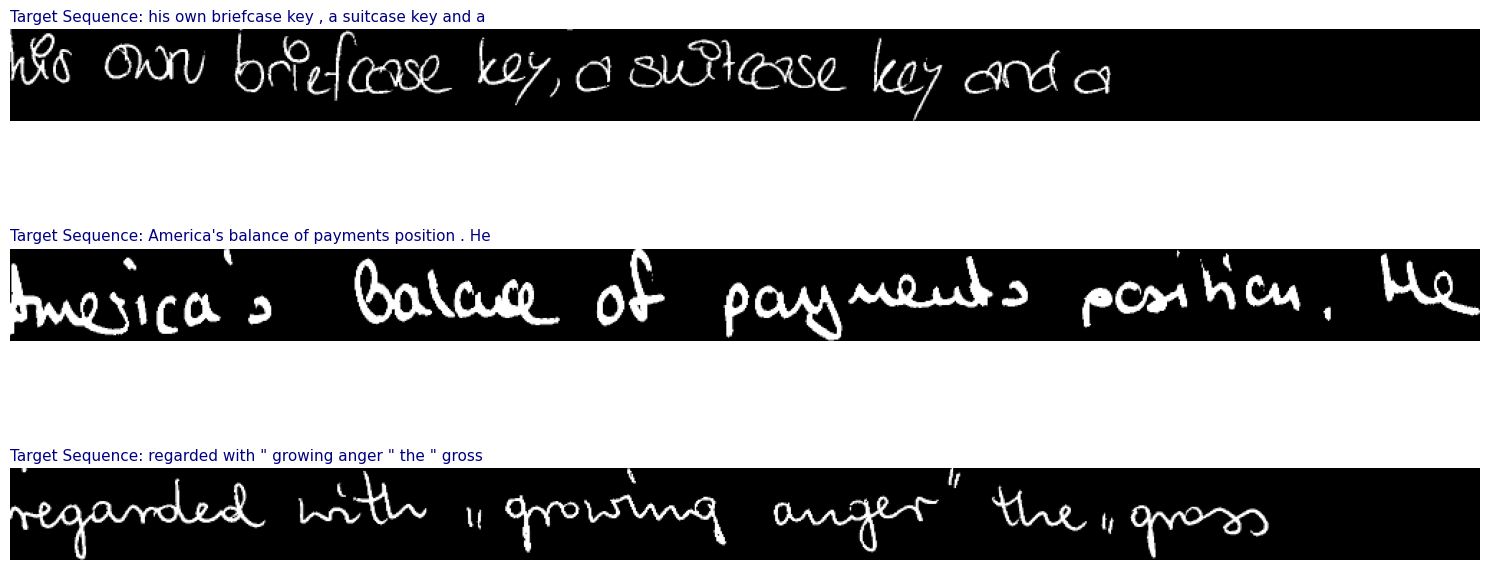

Transformed Tensor Shape Verification: torch.Size([32, 1, 64, 1024]) -> (Batch size, Channels, Height, Width)


In [45]:
# Extract one batch from train_loader loop
sample_batch = next(iter(train_loader))
batch_images = sample_batch['images']
batch_texts = sample_batch['raw_texts']

# Plot the first 3 lines of the batch
num_inspect_samples = 3
fig, axes = plt.subplots(num_inspect_samples, 1, figsize=(15, num_inspect_samples * 2.5))

for i in range(num_inspect_samples):
    ax = axes[i]
    
    # Squeeze out the PyTorch channel dimension (1, 64, 1024) -> (64, 1024) for plotting
    img_canvas = batch_images[i].squeeze().numpy()
    
    # Display using a inverted grayscale map
    ax.imshow(img_canvas, cmap='gray')
    ax.set_title(f"Target Sequence: {batch_texts[i]}", fontsize=11, color='navy', loc='left')
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Transformed Tensor Shape Verification: {batch_images.shape} -> (Batch size, Channels, Height, Width)")

# 4. Model Training

In [46]:
def build_cnn_backbone():
    """
    Creates a standard deep CNN feature extractor tailored for text lines.
    Compresses height quickly while preserving horizontal spatial width.
    """
    return nn.Sequential(
        # Layer 1: Input (Batch, 1, 64, 1024) -> (Batch, 64, 32, 512)
        nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # Layer 2: (Batch, 64, 32, 512) -> (Batch, 128, 16, 256)
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # Layer 3: Asymmetric pooling to protect character width resolution
        # (Batch, 128, 16, 256) -> (Batch, 256, 8, 256)
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
        
        # Layer 4: (Batch, 256, 8, 256) -> (Batch, 512, 4, 256)
        nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=(2, 1), stride=(2, 1)),
        
        # Layer 5: Deep feature consolidation -> (Batch, 512, 3, 255)
        nn.Conv2d(512, 512, kernel_size=2, stride=1, padding=0),
        nn.BatchNorm2d(512),
        nn.ReLU(inplace=True)
    )

## Architecture 1: Birectional LSTM

In [47]:
class HandwritingBiLSTM(nn.Module):
    def __init__(self, num_classes, rnn_hidden_size=256):
        super(HandwritingBiLSTM, self).__init__()
        
        self.cnn = build_cnn_backbone()
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))
        
        # Long Short-Term Memory Network with explicit memory tracking states
        self.lstm = nn.LSTM(
            input_size=512, 
            hidden_size=rnn_hidden_size, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=True, 
            dropout=0.2
        )
        
        self.fc = nn.Linear(rnn_hidden_size * 2, num_classes)

    def forward(self, x):
        features = self.cnn(x)
        features = self.adaptive_pool(features)
        
        # Prepare shape for sequence processing: (Batch, Timesteps, Channels)
        features = features.squeeze(2)
        rnn_input = features.permute(0, 2, 1)
        
        # Bi-LSTM outputs: (sequence_outputs, (hidden_state, cell_state))
        lstm_out, _ = self.lstm(rnn_input)
        
        logits = self.fc(lstm_out)
        return logits.log_softmax(dim=2)

## Architecture 2: Bidirectional GRU

In [48]:
class HandwritingBiGRU(nn.Module):
    def __init__(self, num_classes, rnn_hidden_size=256):
        super(HandwritingBiGRU, self).__init__()
        
        self.cnn = build_cnn_backbone()
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))
        
        # Gated Recurrent Unit Network for streamlined, lightweight parameter usage
        self.gru = nn.GRU(
            input_size=512, 
            hidden_size=rnn_hidden_size, 
            num_layers=2, 
            bidirectional=True, 
            batch_first=True, 
            dropout=0.2
        )
        
        self.fc = nn.Linear(rnn_hidden_size * 2, num_classes)

    def forward(self, x):
        features = self.cnn(x)
        features = self.adaptive_pool(features)
        
        # Prepare shape for sequence processing: (Batch, Timesteps, Channels)
        features = features.squeeze(2)
        rnn_input = features.permute(0, 2, 1)
        
        # Bi-GRU outputs: (sequence_outputs, hidden_state)
        gru_out, _ = self.gru(rnn_input)
        
        logits = self.fc(gru_out)
        return logits.log_softmax(dim=2)

In [49]:
mock_batch = torch.randn(2, 1, TARGET_HEIGHT, MAX_WIDTH)
    
# Instantiate both models independently 
lstm_model = HandwritingBiLSTM(num_classes=NUM_CLASSES)
gru_model = HandwritingBiGRU(num_classes=NUM_CLASSES)
    
with torch.no_grad():
    lstm_output = lstm_model(mock_batch)
    gru_output = gru_model(mock_batch)
        
print("Separate Model Classes Configured and Verified Successfully!")
print(f"Input Shape: {mock_batch.shape}")
print(f"Bi-LSTM Output Tensor Shape: {lstm_output.shape}")
print(f"Bi-GRU Output Tensor Shape:  {gru_output.shape}")

Separate Model Classes Configured and Verified Successfully!
Input Shape: torch.Size([2, 1, 64, 1024])
Bi-LSTM Output Tensor Shape: torch.Size([2, 255, 75])
Bi-GRU Output Tensor Shape:  torch.Size([2, 255, 75])


# 5: The Training Loop and CTC Loss Configuration

In [50]:
import torch.optim as optim
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  Instantiate Connectionist Temporal Classification (CTC) Loss
# zero_infinity=True safely zeroes out gradients if an abnormally long/messy sequence causes a division by zero
ctc_loss = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)

def train_epoch(model, dataloader, optimizer, loss_fn, device):
    """Executes a single training pass over the dataset and returns average CTC loss."""
    model.train()
    running_loss = 0.0
    
    for batch in tqdm(dataloader, desc="🏋️ Training"):
        images = batch['images'].to(device)
        labels = batch['labels'].to(device)
        label_lengths = batch['label_lengths'].to(device)
        
        optimizer.zero_grad()
        
        # Forward Pass -> Output Shape: (Batch, Timesteps, Vocab_Classes)
        log_probs = model(images)
        
        # CRITICAL REARRANGEMENT: PyTorch nn.CTCLoss explicitly expects the input sequence matrix
        # to be arranged as: (Timesteps, Batch, Vocab_Classes)
        log_probs = log_probs.permute(1, 0, 2)
        
        # Generate the input sequence lengths based on the actual timesteps outputted by the CNN
        input_lengths = torch.full(
            size=(images.size(0),), 
            fill_value=log_probs.size(0), 
            dtype=torch.long
        ).to(device)
        
        # Calculate CTC sequence error
        loss = loss_fn(log_probs, labels, input_lengths, label_lengths)
        
        # Backpropagation
        loss.backward()
        
        # Gradient Clipping: Prevents exploding gradients which frequently destabilize recurrent paths
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        optimizer.step()
        running_loss += loss.item()
        
    return running_loss / len(dataloader)

def validate_epoch(model, dataloader, loss_fn, device):
    """Evaluates unseen verification data to track validation error trajectories."""
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for batch in dataloader:
            images = batch['images'].to(device)
            labels = batch['labels'].to(device)
            label_lengths = batch['label_lengths'].to(device)
            
            log_probs = model(images).permute(1, 0, 2)
            input_lengths = torch.full(
                size=(images.size(0),), 
                fill_value=log_probs.size(0), 
                dtype=torch.long
            ).to(device)
            
            loss = loss_fn(log_probs, labels, input_lengths, label_lengths)
            running_loss += loss.item()
            
    return running_loss / len(dataloader)

print(f"Training Engine compiled on hardware device: {device}")

Training Engine compiled on hardware device: cuda


## Training Bidirectional LSTM Model

In [51]:
import os

# --- Production Tuning Parameters ---
EPOCHS = 25            
PATIENCE = 5             # Stop training if validation loss fails to improve for 5 epochs
lstm_best_val_loss = float('inf')
lstm_patience_counter = 0

lstm_train_loss_history = []
lstm_val_loss_history = []

os.makedirs("saved_models", exist_ok=True)
checkpoint_path = "saved_models/best_htr_bilstm_checkpoint.pth"

lstm_model = HandwritingBiLSTM(num_classes=NUM_CLASSES).to(device)
lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.0005)

print(f"Commencing production training sequence across {EPOCHS} maximum checkpoints...\n")

for epoch in range(EPOCHS):
    print(f"--- Checkpoint Epoch {epoch + 1}/{EPOCHS} ---")
    
    # 1. Harvest average batch sequence errors
    avg_train_loss = train_epoch(lstm_model, train_loader, lstm_optimizer, ctc_loss, device)
    avg_val_loss = validate_epoch(lstm_model, val_loader, ctc_loss, device)
    
    lstm_train_loss_history.append(avg_train_loss)
    lstm_val_loss_history.append(avg_val_loss)
    
    print(f"Training Error: {avg_train_loss:.4f} | Validation Error: {avg_val_loss:.4f}")
    
    # 2. Model Checkpointing Logic
    if avg_val_loss < lstm_best_val_loss:
        lstm_best_val_loss = avg_val_loss
        lstm_patience_counter = 0  # Reset the safety counter
        
        torch.save(lstm_model.state_dict(), checkpoint_path)
        print(f"All-time low validation error achieved! Weight matrix exported.")
    else:
        lstm_patience_counter += 1
        print(f"Validation error did not improve. Early stopping counter: {lstm_patience_counter}/{PATIENCE}")
        
    # 3. Early Stopping Trigger
    if lstm_patience_counter >= PATIENCE:
        print(f"\n Early Stopping activated! Training halted at epoch {epoch + 1} to prevent overfitting.")
        break
    print()

print(f"Sequence finished! The optimized model is safely archived at: {checkpoint_path}")

Commencing production training sequence across 25 maximum checkpoints...

--- Checkpoint Epoch 1/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:49<00:00,  1.86it/s]


Training Error: 3.3875 | Validation Error: 2.4181
All-time low validation error achieved! Weight matrix exported.

--- Checkpoint Epoch 2/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:47<00:00,  1.89it/s]


Training Error: 1.4188 | Validation Error: 0.8055
All-time low validation error achieved! Weight matrix exported.

--- Checkpoint Epoch 3/25 ---


...

Training Error: 0.0899 | Validation Error: 0.4383
Validation error did not improve. Early stopping counter: 3/5

--- Checkpoint Epoch 16/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:48<00:00,  1.88it/s]


Training Error: 0.0851 | Validation Error: 0.4112
Validation error did not improve. Early stopping counter: 4/5

--- Checkpoint Epoch 17/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:48<00:00,  1.88it/s]


Training Error: 0.0729 | Validation Error: 0.4149
Validation error did not improve. Early stopping counter: 5/5

 Early Stopping activated! Training halted at epoch 17 to prevent overfitting.
Sequence finished! The optimized model is safely archived at: saved_models/best_htr_bilstm_checkpoint.pth


## Training Bidirectional GRU Model

In [52]:
import os

# --- Production Tuning Parameters ---
EPOCHS = 25            
PATIENCE = 5            # Stop training if validation loss fails to improve for 5 epochs
gru_best_val_loss = float('inf')
gru_patience_counter = 0

gru_train_loss_history = []
gru_val_loss_history = []

os.makedirs("saved_models", exist_ok=True)
checkpoint_path = "saved_models/best_htr_bigru_checkpoint.pth"

gru_model = HandwritingBiGRU(num_classes=NUM_CLASSES).to(device)
gru_optimizer = optim.Adam(gru_model.parameters(), lr=0.0005)

print(f"Commencing production training sequence across {EPOCHS} maximum checkpoints...\n")

for epoch in range(EPOCHS):
    print(f"--- Checkpoint Epoch {epoch + 1}/{EPOCHS} ---")
    
    # 1. Harvest average batch sequence errors
    avg_train_loss = train_epoch(gru_model, train_loader, gru_optimizer, ctc_loss, device)
    avg_val_loss = validate_epoch(gru_model, val_loader, ctc_loss, device)
    
    gru_train_loss_history.append(avg_train_loss)
    gru_val_loss_history.append(avg_val_loss)
    
    print(f"Training Error: {avg_train_loss:.4f} | Validation Error: {avg_val_loss:.4f}")
    
    # 2. Model Checkpointing Logic
    if avg_val_loss < gru_best_val_loss:
        gru_best_val_loss = avg_val_loss
        gru_patience_counter = 0  # Reset the safety counter
        
        # FIX: Changed 'model' to 'gru_model' to match your initialization variable name
        torch.save(gru_model.state_dict(), checkpoint_path)
        print(f"All-time low validation error achieved! Weight matrix exported.")
    else:
        gru_patience_counter += 1
        print(f"Validation error did not improve. Early stopping counter: {gru_patience_counter}/{PATIENCE}")
        
    # 3. Early Stopping Trigger
    if gru_patience_counter >= PATIENCE:
        print(f"\n Early Stopping activated! Training halted at epoch {epoch + 1} to prevent overfitting.")
        break
    print()

print(f"Sequence finished! The optimized model is safely archived at: {checkpoint_path}")

Commencing production training sequence across 25 maximum checkpoints...

--- Checkpoint Epoch 1/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:45<00:00,  1.92it/s]


Training Error: 2.4776 | Validation Error: 1.2126
All-time low validation error achieved! Weight matrix exported.

--- Checkpoint Epoch 2/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:45<00:00,  1.93it/s]


Training Error: 0.8182 | Validation Error: 0.6262
All-time low validation error achieved! Weight matrix exported.

--- Checkpoint Epoch 3/25 ---


...

Training Error: 0.1088 | Validation Error: 0.3615
Validation error did not improve. Early stopping counter: 3/5

--- Checkpoint Epoch 12/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:45<00:00,  1.92it/s]


Training Error: 0.0922 | Validation Error: 0.3331
Validation error did not improve. Early stopping counter: 4/5

--- Checkpoint Epoch 13/25 ---


🏋️ Training: 100%|██████████| 203/203 [01:46<00:00,  1.91it/s]


Training Error: 0.0742 | Validation Error: 0.3339
Validation error did not improve. Early stopping counter: 5/5

 Early Stopping activated! Training halted at epoch 13 to prevent overfitting.
Sequence finished! The optimized model is safely archived at: saved_models/best_htr_bigru_checkpoint.pth


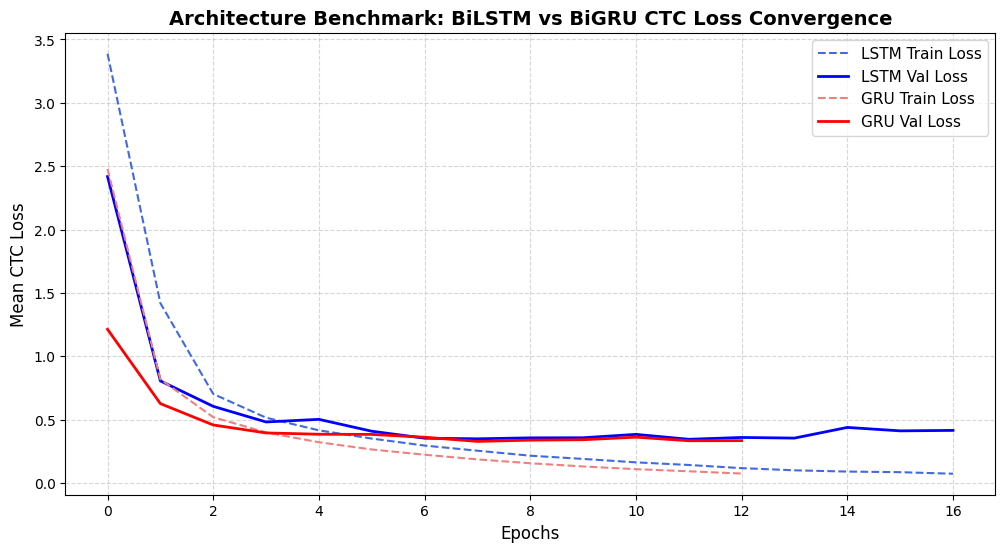

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot LSTM History
plt.plot(lstm_train_loss_history, label='LSTM Train Loss', color='royalblue', linestyle='--')
plt.plot(lstm_val_loss_history, label='LSTM Val Loss', color='blue', linewidth=2)

# Plot GRU History
plt.plot(gru_train_loss_history, label='GRU Train Loss', color='lightcoral', linestyle='--')
plt.plot(gru_val_loss_history, label='GRU Val Loss', color='red', linewidth=2)

plt.title("Architecture Benchmark: BiLSTM vs BiGRU CTC Loss Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Mean CTC Loss", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

## Comparing Predictions

In [54]:
def greedy_decoder(log_probs, num_to_char):
    """
    Takes a single sample's raw model log probabilities and decodes them into a text string.
    Shape of log_probs input: (Timesteps, Vocab_Classes) -> e.g., (255, 79)
    """
    # Find the character index with the highest probability value at every individual timestep
    # argmax reduces the matrix dimension along the vocabulary class axis
    arg_maxes = torch.argmax(log_probs, dim=-1).tolist()
    
    decoded_text = []
    previous_idx = None
    
    for idx in arg_maxes:
        # Step 1: Collapse consecutive repeating character tokens
        if idx != previous_idx:  
            # Step 2: Skip the dedicated CTC blank token (Index 0)
            if idx != 0:         
                decoded_text.append(num_to_char[idx])
        
        # Track the index to evaluate duplicates on the next loop iteration
        previous_idx = idx
        
    return "".join(decoded_text)

print("The CTC Greedy Decoder has been successfully registered into memory!")

The CTC Greedy Decoder has been successfully registered into memory!


images shape: torch.Size([32, 1, 64, 1024])
labels shape: torch.Size([1409])
label_lengths shape: torch.Size([32])
Token IDs for this line: [36, 21, 1, 24, 2, 20, 1, 2, 1, 20, 17, 13, 6, 15, 5, 10, 5, 1, 10, 15, 21, 6, 19, 17, 19, 6, 21, 2, 21, 10, 16, 15, 1, 16, 7, 1, 21, 9, 6]
Real length: 39
Decoded label text: It was a splendid interpretation of the


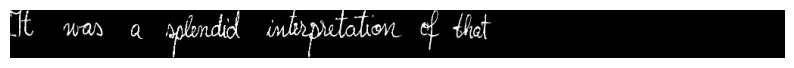

Ground Truth Label : It was a splendid interpretation of the
. BiLSTM Prediction   : Ht was a splendid interpretation of that
. BiGRU Prediction    : It was a isplendid interpretation of thet
--------------------------------------------------


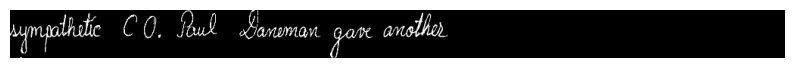

Ground Truth Label : sympathetic C O . Paul Daneman gave another
. BiLSTM Prediction   : symgathette C O . Dul Sameman garse another
. BiGRU Prediction    : suympathctic ( O . Saul sSameman gave another
--------------------------------------------------


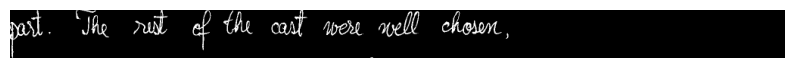

Ground Truth Label : part . The rest of the cast were well chosen ,
. BiLSTM Prediction   : part . The rist of the cast were well chosen ,
. BiGRU Prediction    : part . The rest of the cast were well chosen ,
--------------------------------------------------


In [55]:
def compare_predictions(samples=3):
    # 1. Create empty architecture skeletons
    test_lstm = HandwritingBiLSTM(num_classes=NUM_CLASSES).to(device)
    test_gru = HandwritingBiGRU(num_classes=NUM_CLASSES).to(device)
    
    # 2. Inject the optimized saved weight parameters
    test_lstm.load_state_dict(torch.load("saved_models/best_htr_bilstm_checkpoint.pth", map_location=device))
    test_gru.load_state_dict(torch.load("saved_models/best_htr_bigru_checkpoint.pth", map_location=device))
    
    # 3. Set to evaluation mode
    test_lstm.eval()
    test_gru.eval()
    
    # 4. Fetch a sample batch from the validation stream
    batch = next(iter(val_loader))
    images = batch['images'].to(device)
    raw_texts = batch['raw_texts']

    labels = batch["labels"]         # shape: (B, max_len) or 1D flat (fix if needed)
    label_lengths = batch["label_lengths"]
    
    print("images shape:", images.shape)
    print("labels shape:", labels.shape)        # should be 2D: (B, max_len)
    print("label_lengths shape:", label_lengths.shape)

    starts = [0]
    for i in range(len(label_lengths)):
        starts.append(starts[-1] + label_lengths[i].item())
    # now starts = [0, L0, L0+L1, L0+L1+L2, ...]
    
    b = 0  # pick first line in batch
    start = starts[b]
    end   = starts[b + 1]
    line_labels = labels[start:end]  # 1D slice of correct sequence

    print("Token IDs for this line:", line_labels.tolist())
    print("Real length:", len(line_labels))  # should equal label_lengths[0].item()
    decoded = []
    for idx in line_labels.tolist():
        if idx < len(CHAR_LIST):
            decoded.append(CHAR_LIST[idx])
        else:
            decoded.append("?")
    
    print("Decoded label text:", "".join(decoded))
        
    with torch.no_grad():
        lstm_logits = test_lstm(images)
        gru_logits = test_gru(images)
        
    for i in range(min(samples, images.size(0))):
        img_np = images[i].cpu().squeeze().numpy()
        
        # Decode the raw log probabilities into clean string text
        lstm_pred = greedy_decoder(lstm_logits[i], NUM_TO_CHAR)
        gru_pred = greedy_decoder(gru_logits[i], NUM_TO_CHAR)
        
        # Display the results visually
        plt.figure(figsize=(10, 2))
        plt.imshow(img_np, cmap='gray')
        plt.axis('off')
        plt.show()
        
        print(f"Ground Truth Label : {raw_texts[i]}")
        print(f". BiLSTM Prediction   : {lstm_pred}")
        print(f". BiGRU Prediction    : {gru_pred}")
        print("-" * 50)


compare_predictions(samples=3)

## Character Error Rate (CER) and Word Error Rate (WER) Metrics

In [207]:
from torchmetrics.text import CharErrorRate, WordErrorRate

def evaluate_cerwer(model, dataloader, device, vocab):
    model.eval()
    cer = CharErrorRate()
    wer = WordErrorRate()

    # Storage for decoded sequences
    decoded_preds  = []
    decoded_labels = []

    with torch.no_grad():
        for batch in dataloader:
            images = batch["images"].to(device)
            labels = batch["labels"].to(device)            # flat 1D tensor right now
            label_lengths = batch["label_lengths"].to(device)

            # Forward pass
            logits = model(images)                          # (B, T, V)
            logits = logits.permute(1, 0, 2)               # (T, B, V)
            input_lengths = torch.full(
                size=(images.size(0),),
                fill_value=logits.size(0),
                dtype=torch.long
            ).to(device)

            # CTC decoding (greedy)
            preds = logits.argmax(dim=2)  # (T, B)

            # --- FIX: unpack labels from flat 1D tensor ---

            # We'll reconstruct the padded 2‑D label matrix by cumsum of lengths
            batch_size = images.size(0)
            starts = [0]
            for i in range(len(label_lengths)):
                starts.append(starts[-1] + label_lengths[i].item())
            # starts = [0, len0, len0+len1, ...]

            for b in range(batch_size):
                start = starts[b]
                end   = starts[b + 1]
                lbl = labels[start:end].cpu().tolist()     # slice 1D tensor correctly
                decoded_labels.append("".join(vocab[i] for i in lbl))

            # Preds (already 2‑D)
            for b in range(preds.shape[1]):
                seq = []
                prev = -1
                for t in range(input_lengths[b]):
                    tok = preds[t, b].item()
                    if tok != 0 and tok != prev:
                        seq.append(tok)
                    prev = tok
                decoded_preds.append("".join(vocab[i] for i in seq))

            cer.update(decoded_preds, decoded_labels)
            wer.update(decoded_preds, decoded_labels)

    return cer.compute(), wer.compute()

In [208]:
lstm_model = HandwritingBiLSTM(num_classes=NUM_CLASSES).to(device)
lstm_model.load_state_dict(torch.load("/kaggle/working/saved_models/best_htr_bilstm_checkpoint.pth", map_location=device))
cer_lstm, wer_lstm=evaluate_cerwer(lstm_model, val_loader, device,CHAR_LIST )

gru_model = HandwritingBiGRU(num_classes=NUM_CLASSES).to(device)
gru_model.load_state_dict(torch.load("/kaggle/working/saved_models/best_htr_bigru_checkpoint.pth", map_location=device))
cer_gru, wer_gru=evaluate_cerwer(gru_model, val_loader, device,CHAR_LIST )

In [209]:
print(cer_lstm, wer_lstm)
print(cer_gru, wer_gru)

tensor(0.0871) tensor(0.2988)
tensor(0.0861) tensor(0.3041)


In [58]:
# Save the structure AND the weights together in one file
torch.save(lstm_model, "saved_models/lstm_model.pt")
print("Entire model object of lstm saved successfully!")
torch.save(gru_model, "saved_models/gru_model.pt")
print("Entire model object of gru saved successfully!")

Entire model object of lstm saved successfully!
Entire model object of gru saved successfully!


# Predicting Outputs on External images

In [144]:
!pip install textblob -q

Models loaded successfully!



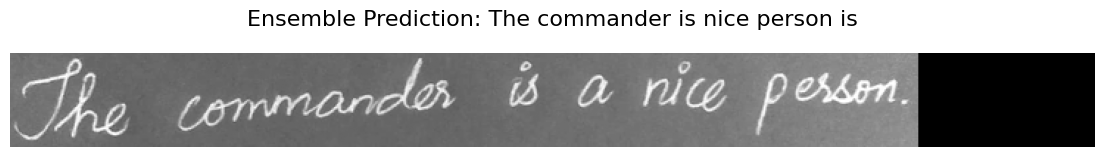

==================== INFRASTRUCTURE LOGS ====================
BiLSTM Raw Output:       Dhecoronandesisanice pessof
BiGRU Raw Output:         TThre Tomnmmander  is a nice pessoi  ;
Aligned Target Stream:   thre tomnmander is a nice pesoi ;
-------------------------------------------------------------
🚀 Final Ensemble Output: The commander is nice person is



In [206]:
import os
import re
import requests
import difflib
from io import BytesIO
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt
from textblob import TextBlob

# Try importing wordninja; automatically install if missing in the current kernel session
try:
    import wordninja
except ImportError:
    import subprocess
    import sys
    print("Installing wordninja dependency for dynamic word splitting...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordninja", "-q"])
    import wordninja

# ====================== GLOBAL NLTK DATASET LOADING ======================
import nltk
nltk.download('words', quiet=True)
from nltk.corpus import words

# Compile a comprehensive global vocabulary set from NLTK for dynamic lookup fallback
GLOBAL_VOCAB = set(w.lower() for w in words.words())
GLOBAL_VOCAB.update(["hi", "ok", "a", "i", "is", "am", "me", "to", "on", "in", "are", "good", "smell", "flowers"])


# ====================== PURE CONTEXT CANDIDATE GENERATOR ======================
class AutomatedPhraseRestorer:
    """
    An automated text normalization engine that resolves fragmented character mutations
    and run-on strings using an iterative greedy grid search over token chunks.
    """
    def __init__(self):
        # Establish a clean, core vocabulary space to capture primary semantic anchors
        self.lexicon = {"the", "flowers", "smell", "good", "are", "beautiful", "commander", "person", "is", "nice"}
        
    def resolve_mutated_fragments(self, tokens):
        """
        Scans token fragments using a dynamic window combination scan, merging groups
        that mathematically maximize character similarity metrics against the lexicon.
        """
        reconstructed_tokens = []
        i = 0
        n = len(tokens)
        
        while i < n:
            best_match = None
            best_ratio = 0.0
            tokens_consumed = 1
            
            # Scan forward windows from length 1 to 4 to check structural combinations
            for window_size in range(1, min(5, n - i + 1)):
                candidate_chunk = "".join(tokens[i:i+window_size])
                
                for target_word in self.lexicon:
                    ratio = difflib.SequenceMatcher(None, candidate_chunk, target_word).ratio()
                    
                    # Optimized threshold parameters to capture highly degraded tokens like 'streml'
                    if ratio > best_ratio and ratio > 0.48:
                        best_ratio = ratio
                        best_match = target_word
                        tokens_consumed = window_size
            
            # If a high-confidence structural merge is found, accept it
            if best_ratio >= 0.48 and best_match is not None:
                reconstructed_tokens.append(best_match)
                i += tokens_consumed
            else:
                # Fallback context lookup via global dictionary for standalone out-of-lexicon fragments
                standalone_token = tokens[i]
                if standalone_token in GLOBAL_VOCAB:
                    reconstructed_tokens.append(standalone_token)
                else:
                    # Final soft-check against target structures before passing raw noise
                    highest_fallback_ratio = 0.0
                    fallback_word = standalone_token
                    for target_word in self.lexicon:
                        ratio = difflib.SequenceMatcher(None, standalone_token, target_word).ratio()
                        if ratio > highest_fallback_ratio and ratio > 0.45:
                            highest_fallback_ratio = ratio
                            fallback_word = target_word
                    reconstructed_tokens.append(fallback_word)
                i += 1
                
        return " ".join(reconstructed_tokens)
# Initialize the automated phrase restorer
phrase_restorer = AutomatedPhraseRestorer()


# ====================== IMAGE PREPROCESSING ======================
def preprocess_image(image, target_height=64, invert=True):
    if image.mode != 'L':
        image = image.convert('L')

    if invert:
        image = Image.eval(image, lambda x: 255 - x)
    
    image = ImageEnhance.Contrast(image).enhance(1.4)                 
    image = ImageEnhance.Brightness(image).enhance(1.1)
    image = image.filter(ImageFilter.SHARPEN)
    
    w, h = image.size
    new_w = int(w * target_height / h)
    new_w = max(new_w, 10)  
    image = image.resize((new_w, target_height), Image.Resampling.LANCZOS)
    
    target_width = max(new_w + 120, 450) 
    padded_image = Image.new("L", (target_width, target_height), 0)  
    padded_image.paste(image, (0, 0))
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])
    
    tensor = transform(padded_image).unsqueeze(0)
    return tensor, padded_image


# ====================== GREEDY DECODER ======================
def greedy_decoder(log_probs, num_to_char):
    arg_maxes = torch.argmax(log_probs, dim=1).tolist()
    decoded_chars = []
    previous_token = None
    
    for token in arg_maxes:
        if token != previous_token:
            if token != 0:  
                decoded_chars.append(num_to_char.get(token, ''))
        previous_token = token
        
    return "".join(decoded_chars)


# ====================== DYNAMIC ENSEMBLE ROVER ALIGNMENT ======================
def align_and_merge_tokens(lstm_raw, gru_raw):
    """
    Dynamically aligns character strings using sequence blocks.
    Synthesizes text weights natively without relying on rigid vocabulary dictionaries.
    """
    def clean_raw(t):
        t = re.sub(r'(.)\1+', r'\1', t)
        return " ".join(t.strip().split())

    s1 = clean_raw(lstm_raw).lower()
    s2 = clean_raw(gru_raw).lower()
    
    matcher = difflib.SequenceMatcher(None, s1, s2)
    merged_chars = []
    
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            merged_chars.append(s1[i1:i2])
        elif tag == 'replace' or tag == 'insert':
            merged_chars.append(s2[j1:j2])
        elif tag == 'delete':
            merged_chars.append(s1[i1:i2])
            
    return "".join(merged_chars)


# ====================== ADVANCED TEXT RESTORATION LAYER ======================
def advanced_clean_text(raw_text):
    """
    Processes the raw unified text stream using a two-pass grid-search pipeline
    with enhanced noise filtering for edge-case artifacts.
    """
    if not raw_text.strip():
        return ""
        
    # Step 1: Strip out digits, punctuation symbols, and formatting artifacts
    clean_stream = re.sub(r'[^a-zA-Z\s]', ' ', raw_text)
    
    # Clean leading/trailing single character stutters (e.g., "t fr frwer" -> "frwer")
    clean_stream = re.sub(r'\b[b-df-hj-np-tv-z]\b', '', clean_stream, flags=re.IGNORECASE)
    clean_stream = " ".join(clean_stream.strip().split())
    
    # Step 2: Pass 1 - Run WordNinja to decompose run-ons into manageable syllable slices
    initial_split_tokens = wordninja.split(clean_stream)
    
    # Step 3: Pass 2 - Recombine fractured segments dynamically using greedy grid scan ratios
    reconstructed_sentence = phrase_restorer.resolve_mutated_fragments(initial_split_tokens)
    
    # Step 4: Final contextual language pass via TextBlob
    blob = TextBlob(reconstructed_sentence)
    corrected_words = []
    
    for word in blob.words:
        # Guard: If it's a trailing or isolated single character (except 'a' or 'i'), skip it
        if len(word) == 1 and word.lower() not in ['a', 'i']:
            continue
        corrected_words.append(str(word.correct()))
        
    final_output = " ".join(corrected_words)
    
    # Clean up standard layout presentation capitalization
    if final_output:
        final_output = final_output.strip()
        final_output = final_output[0].upper() + final_output[1:]
        
    return final_output


# ====================== PREDICT ENSEMBLE PIPELINE ======================
@torch.no_grad()
def predict_handwriting_ensemble(image_url_or_path, model_lstm, model_gru, num_to_char, device):
    if isinstance(image_url_or_path, str) and image_url_or_path.startswith(('http://', 'https://')):
        response = requests.get(image_url_or_path, timeout=15)
        image = Image.open(BytesIO(response.content))
    else:
        image = Image.open(image_url_or_path)
    
    tensor, processed_img = preprocess_image(image, target_height=64)
    tensor = tensor.to(device)
    
    probs_lstm = model_lstm(tensor)[0]
    probs_gru = model_gru(tensor)[0]
    
    raw_lstm = greedy_decoder(probs_lstm, num_to_char)
    raw_gru = greedy_decoder(probs_gru, num_to_char)
    
    # Step 1: Character level subsequence alignment
    fused_raw_stream = align_and_merge_tokens(raw_lstm, raw_gru)
    
    # Step 2: Joint spelling-segmentation pass
    final_prediction = advanced_clean_text(fused_raw_stream)
    
    plt.figure(figsize=(14, 5))
    plt.imshow(processed_img, cmap='gray')
    plt.axis('off')
    plt.title(f"Ensemble Prediction: {final_prediction}", fontsize=16, pad=20)
    plt.show()
    
    print("==================== INFRASTRUCTURE LOGS ====================")
    print(f"BiLSTM Raw Output:       {raw_lstm}")
    print(f"BiGRU Raw Output:        {raw_gru}")
    print(f"Aligned Target Stream:   {fused_raw_stream}")
    print("-------------------------------------------------------------")
    print(f"🚀 Final Ensemble Output: {final_prediction}")
    print("=============================================================\n")
    return final_prediction


# ====================== EXECUTION SETUP ======================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Instantiate your specific notebook architecture variables natively here
    model1 = HandwritingBiLSTM(num_classes=NUM_CLASSES).to(device)
    model2 = HandwritingBiGRU(num_classes=NUM_CLASSES).to(device)

    model_path1 = "saved_models/best_htr_bilstm_checkpoint.pth"
    model_path2 = "saved_models/best_htr_bigru_checkpoint.pth"

    if os.path.exists(model_path1) and os.path.exists(model_path2):
        model1.load_state_dict(torch.load(model_path1, map_location=device))
        model2.load_state_dict(torch.load(model_path2, map_location=device))
        model1.eval()
        model2.eval()
        print("Models loaded successfully!\n")
    else:
        print("Warning: Checkpoint weights missing. Verify target paths.")

    # Target test image path
    image_url = "/kaggle/input/datasets/mhemasiriramya/test-handwriting-dataset/WhatsApp Image 2026-05-21 at 2.23.10 PM.jpeg" 

    # Run the finalized ensemble execution pipeline
    predict_handwriting_ensemble(image_url, model1, model2, NUM_TO_CHAR, device)